In [39]:
import sys
sys.path.insert(0, '../..')

from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit.result import marginal_counts, marginal_distribution

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_ibm_runtime.fake_provider import FakeFez

from qiskit.visualization import plot_histogram

import os
import pickle
import numpy as np
import networkx as nx

# Import from network_emulation (only what we need - no remap_noise_model)
from network_emulation import (
    # Static mappings
    NODE_PHYSICAL_QUBITS_513,
    EDGE_PHYSICAL_QUBITS_ES,
    PATH_PHYSICAL_QUBITS_ES,
    TOTAL_QUBITS_ES,
    get_edge_key,
    # Dynamic allocation (used for compact mapping only)
    PathQubitAllocation,
    # Code operations
    apply_encoding_513,
    apply_syndrome_measurement_513,
)

# [[5,1,3]] Code Transport via Entanglement Swapping

This notebook implements quantum state transport using entanglement swapping instead of direct SWAP chains.

## Protocol Overview

For a path A → B → C → D:

1. **Bell Pair Distribution**: Create noisy Bell pairs on each edge
2. **Entanglement Swapping**: At intermediate nodes, perform Bell measurements to extend entanglement
3. **Teleportation**: Bell measurement at source teleports encoded state to sink
4. **Syndrome Measurement**: Extract syndrome at sink (no corrections applied)

# Constants and Configuration

In [40]:
MAX_HOPS = 3
MIN_HOPS = 2
NUM_SHOTS = 4096
OPTIMIZATION_LEVEL = 0


SEED = 1234
SKIP_EXISTING_PATHS = False
NETWORK_GRAPH = '../../networkgraphs/2x3_grid_network_graph.pkl'

# Physical Qubit Mapping - FIXED ALLOCATION

## Strategy for Consistent Noise Profiles:
- **Source data**: Always qubits [0-4] (consistent encoding noise)
- **Sink ancilla**: Always qubits [5-8] (consistent syndrome measurement noise)
- **Edge qubits**: Fixed per-edge mapping (edge (i,j) always uses same qubit range)

This ensures that:
1. Edge (A,B) gets the **same noise profile** regardless of which path it appears in
2. Source encoding always experiences the same noise
3. Sink syndrome measurement always experiences the same noise

## Layout for 2×3 Grid (7 edges):
```
Total = 5 (source) + 4 (ancilla) + 7 × 11 (edges) = 86 qubits
```

In [41]:
# Fixed allocation will be computed after loading the network graph.
# 
# Key features:
# - Source data: ALWAYS qubits 0-4 (consistent noise for encoding)
# - Sink ancilla: ALWAYS qubits 5-8 (consistent noise for syndrome)
# - Edge qubits: FIXED per-edge mapping (consistent noise per edge)
#
# This ensures that edge (A,B) gets the SAME noise profile whether it
# appears in path [A,B,C] or path [X,A,B,Y].

# Noise Model Setup

## Clean Depolarizing Noise Model
- **1Q errors**: Depolarizing errors from FakeFez gate error properties
- **2Q errors**: Custom all-to-all depolarizing with configurable error rate
- **No complex remapping** - simpler, more controllable, and matches cloud_runs approach

This replaces the previous approach that used `NoiseModel.from_backend()` with remapping.

In [42]:
# =============================================================================
# NOISE MODEL SETUP (Clean Depolarizing Model for FIXED Allocation)
# =============================================================================
# With fixed allocation, we build ONE noise model for all paths!
# This ensures consistent noise profiles across the entire simulation.

from qiskit_aer.noise import NoiseModel, depolarizing_error

fake_backend = FakeFez()

# FakeFez native gates: cz (2Q), id, rz, sx, x (1Q)
FEZ_BASIS_GATES = ["cz", "id", "rz", "sx", "x"]

# Default 2Q error rate (can be adjusted)
ERROR_RATE_2Q = 0.01


def build_fixed_noise_model(total_qubits: int, error_rate_2q: float = 0.01):
    """
    Build a noise model for fixed allocation circuits.
    
    With fixed allocation, all circuits use the same qubit indices,
    so we can build ONE noise model and reuse it for all paths.
    
    Args:
        total_qubits: Total qubits in the fixed allocation (TOTAL_FIXED_QUBITS)
        error_rate_2q: 2Q depolarizing error rate
    
    Returns:
        NoiseModel with depolarizing errors
    """
    target = fake_backend.target
    noise_model = NoiseModel()
    
    # --- 1. Add 1Q DEPOLARIZING ERRORS from FakeFez ---
    # These are applied to qubits 0 to total_qubits-1
    gates_to_use = ['sx', 'x', 'rz', 'id']
    for gate in gates_to_use:
        if gate not in target.operation_names:
            continue
        for qargs in target.qargs_for_operation_name(gate):
            phys_qubit = qargs[0]
            # Only add errors for qubits within our circuit range
            if phys_qubit < total_qubits:
                props = target[gate][qargs]
                if props and props.error and props.error > 0:
                    depol_err = depolarizing_error(props.error, 1)
                    noise_model.add_quantum_error(depol_err, gate, [phys_qubit])
    
    # --- 2. Add CUSTOM 2Q GATE ERRORS (all-to-all for circuit qubits) ---
    # FakeFez only has CZ as 2Q gate
    error_2q = depolarizing_error(error_rate_2q, 2)
    
    for i in range(total_qubits):
        for j in range(i + 1, total_qubits):
            noise_model.add_quantum_error(error_2q, 'cz', [i, j])
            noise_model.add_quantum_error(error_2q, 'cz', [j, i])
    
    return noise_model


print(f"Backend: {fake_backend.name} ({fake_backend.num_qubits} qubits)")
print(f"Basis gates: {FEZ_BASIS_GATES}")
print(f"Default 2Q error rate: {ERROR_RATE_2Q}")
print("Noise model: 1Q depolarizing (from FakeFez) + custom 2Q depolarizing (all-to-all)")
print("")
print("NOTE: With FIXED allocation, we build ONE noise model for all paths!")

Backend: fake_fez (156 qubits)
Basis gates: ['cz', 'id', 'rz', 'sx', 'x']
Default 2Q error rate: 0.01
Noise model: 1Q depolarizing (from FakeFez) + custom 2Q depolarizing (all-to-all)

NOTE: With FIXED allocation, we build ONE noise model for all paths!


# Load Network Graph

FIXED ALLOCATION MAPPING (Consistent Noise)
Network: 6 nodes, 7 edges

Source data qubits:  [0, 1, 2, 3, 4]
Sink ancilla qubits: [5, 6, 7, 8]

Edge qubit assignments:
  Edge (0, 1): Bell pairs 9-18, Path qubit 19
  Edge (0, 3): Bell pairs 20-29, Path qubit 30
  Edge (1, 2): Bell pairs 31-40, Path qubit 41
  Edge (1, 4): Bell pairs 42-51, Path qubit 52
  Edge (2, 5): Bell pairs 53-62, Path qubit 63
  Edge (3, 4): Bell pairs 64-73, Path qubit 74
  Edge (4, 5): Bell pairs 75-84, Path qubit 85

Total qubits: 86 (FakeFez has 156)


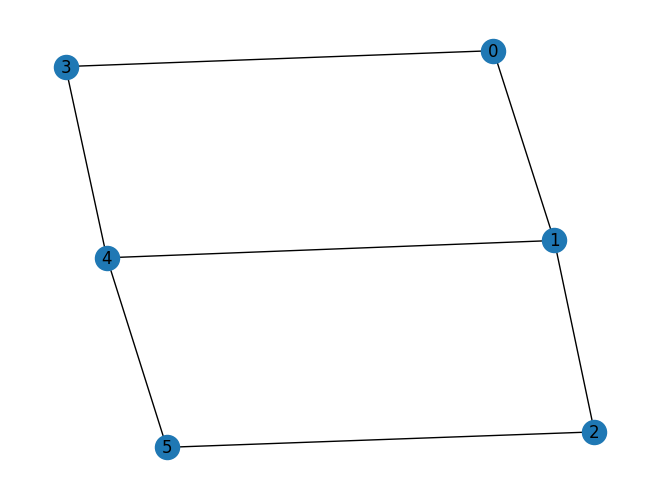

In [43]:
with open(NETWORK_GRAPH, 'rb') as f:
    network_graph = pickle.load(f)

nx.draw(network_graph, with_labels=True)

# =============================================================================
# FIXED ALLOCATION MAPPING (Consistent Noise Profiles)
# =============================================================================
# This mapping ensures that:
# - Source data qubits are ALWAYS at indices 0-4
# - Sink ancilla qubits are ALWAYS at indices 5-8
# - Each edge (i,j) ALWAYS uses the same qubit range, regardless of path
#
# This guarantees consistent noise profiles across all paths.

_nodes = sorted(network_graph.nodes())
_edges = sorted({get_edge_key(u, v) for u, v in network_graph.edges()})

# --- Fixed qubit ranges ---
# Source data: always qubits 0-4
SOURCE_DATA_QUBITS = list(range(0, 5))

# Sink ancilla: always qubits 5-8
SINK_ANCILLA_QUBITS = list(range(5, 9))

# Edge qubits: each edge gets a fixed range
# Edge stride = 10 (Bell pairs) + 1 (path qubit) = 11
EDGE_STRIDE = 11
EDGE_BASE = 9  # Start after source data + sink ancilla

FIXED_EDGE_BELL_QUBITS = {}  # edge -> [10 Bell pair qubits]
FIXED_EDGE_PATH_QUBIT = {}   # edge -> 1 path qubit

for edge_idx, edge in enumerate(_edges):
    start = EDGE_BASE + edge_idx * EDGE_STRIDE
    FIXED_EDGE_BELL_QUBITS[edge] = list(range(start, start + 10))
    FIXED_EDGE_PATH_QUBIT[edge] = start + 10

TOTAL_FIXED_QUBITS = EDGE_BASE + len(_edges) * EDGE_STRIDE

if TOTAL_FIXED_QUBITS > fake_backend.num_qubits:
    raise ValueError(
        f"Fixed allocation requires {TOTAL_FIXED_QUBITS} qubits, "
        f"but backend provides {fake_backend.num_qubits}."
    )

print("=" * 60)
print("FIXED ALLOCATION MAPPING (Consistent Noise)")
print("=" * 60)
print(f"Network: {len(_nodes)} nodes, {len(_edges)} edges")
print(f"")
print(f"Source data qubits:  {SOURCE_DATA_QUBITS}")
print(f"Sink ancilla qubits: {SINK_ANCILLA_QUBITS}")
print(f"")
print("Edge qubit assignments:")
for edge in _edges:
    bell = FIXED_EDGE_BELL_QUBITS[edge]
    path = FIXED_EDGE_PATH_QUBIT[edge]
    print(f"  Edge {edge}: Bell pairs {bell[0]}-{bell[-1]}, Path qubit {path}")
print(f"")
print(f"Total qubits: {TOTAL_FIXED_QUBITS} (FakeFez has {fake_backend.num_qubits})")
print("=" * 60)

In [44]:
from itertools import combinations

ALL_HOP_PATHS = []
for pairs in combinations(network_graph.nodes, 2):
    multi_hop_paths = nx.all_simple_paths(network_graph, source=pairs[0], target=pairs[1], cutoff=MAX_HOPS)
    ALL_HOP_PATHS.extend([x for x in multi_hop_paths if len(x) > MIN_HOPS])

print(f"Total paths to process: {len(ALL_HOP_PATHS)}")
print(f"Sample paths: {ALL_HOP_PATHS[:5]}")

Total paths to process: 24
Sample paths: [[0, 3, 4, 1], [0, 1, 2], [0, 1, 4, 3], [0, 1, 4], [0, 3, 4]]


# [[5,1,3]] Code Helpers

Stabilizers: XZZXI, IXZZX, XIXZZ, ZXIXZ

In [45]:
# [[5,1,3]] code functions imported from network_emulation:
# - apply_encoding_513(qc, qubits)
# - apply_syndrome_measurement_513(qc, data_qubits, ancilla_qubits, classical_bits)

print("[[5,1,3]] Code:")
print("  Stabilizers: XZZXI, IXZZX, XIXZZ, ZXIXZ")
print("  5 data qubits, 4 ancilla qubits")
print("  Corrects any single-qubit error")

[[5,1,3]] Code:
  Stabilizers: XZZXI, IXZZX, XIXZZ, ZXIXZ
  5 data qubits, 4 ancilla qubits
  Corrects any single-qubit error


# Entanglement Swapping Primitives

In [46]:
# =============================================================================
# ENTANGLEMENT PRIMITIVES
# =============================================================================

def create_and_distribute_bell_pair(qc, local_qubit, remote_qubit, path_qubit):
    """
    Create a Bell pair locally and distribute one half via physical SWAP.
    
    Protocol:
        1. Create Bell pair: |Φ+⟩ = (|00⟩ + |11⟩)/√2 between local_qubit and path_qubit
        2. SWAP path_qubit to remote_qubit (this is the noisy channel)
    
    Result: local_qubit and remote_qubit share a Bell pair.
    
    Args:
        qc: QuantumCircuit
        local_qubit: Qubit index that stays at the sender
        remote_qubit: Qubit index at the receiver (destination)
        path_qubit: Channel qubit used for physical transport
    """
    # Create Bell pair between local qubit and path qubit
    qc.h(local_qubit)
    qc.cx(local_qubit, path_qubit)
    
    # SWAP path qubit to remote qubit (noisy channel operation)
    qc.swap(path_qubit, remote_qubit)


def distribute_bell_pairs_sequential(qc, sender_qubits, receiver_qubits, path_qubit):
    """
    Distribute 5 Bell pairs from sender to receiver via physical SWAPs.
    
    Each of the 5 code qubits gets its own Bell pair:
        - sender_qubits[i] holds one half
        - receiver_qubits[i] holds the other half (after SWAP through channel)
    
    Args:
        qc: QuantumCircuit
        sender_qubits: List of 5 qubit indices at sender node
        receiver_qubits: List of 5 qubit indices at receiver node
        path_qubit: Single path qubit index (channel) - reused for all 5 pairs
    """
    for i in range(5):
        create_and_distribute_bell_pair(qc, sender_qubits[i], receiver_qubits[i], path_qubit)


def apply_bell_measurement(qc, qubits_a, qubits_b, classical_bits):
    """
    Perform Bell measurements on pairs of qubits.
    
    Bell measurement: CNOT(a→b), H(a), then measure both.
    
    Measurement outcomes encode required Pauli corrections:
        classical_bits[i]   (from qubit_a after H) → Z correction needed if 1
        classical_bits[i+5] (from qubit_b)         → X correction needed if 1
    
    Args:
        qc: QuantumCircuit
        qubits_a: List of 5 qubit indices (control)
        qubits_b: List of 5 qubit indices (target)
        classical_bits: List/register of 10 classical bits
    """
    for i, (qa, qb) in enumerate(zip(qubits_a, qubits_b)):
        qc.cx(qa, qb)
        qc.h(qa)
        qc.measure(qa, classical_bits[i])       # Z correction bit
        qc.measure(qb, classical_bits[i + 5])   # X correction bit


def apply_pauli_corrections(qc, target_qubits, classical_register):
    """
    Apply Pauli corrections based on Bell measurement outcomes.
    
    For teleportation/swapping to work correctly:
        - If classical_bits[i] = 1 → apply Z to target[i]
        - If classical_bits[i+5] = 1 → apply X to target[i]
    
    Multiple corrections from different measurements can be applied
    independently - they XOR correctly (Z² = X² = I).
    
    Args:
        qc: QuantumCircuit
        target_qubits: List of 5 qubit indices to correct
        classical_register: ClassicalRegister with 10 bits from Bell measurement
    """
    for i in range(5):
        # Z correction based on first measurement (bits 0-4)
        with qc.if_test((classical_register[i], 1)):
            qc.z(target_qubits[i])
        
        # X correction based on second measurement (bits 5-9)
        with qc.if_test((classical_register[i + 5], 1)):
            qc.x(target_qubits[i])

# Main Circuit Builder: Entanglement Swapping Protocol

In [47]:
# =============================================================================
# CIRCUIT BUILDERS - FIXED ALLOCATION
# =============================================================================

class FixedPathAllocation:
    """
    Fixed qubit allocation for consistent noise profiles across paths.
    
    Key properties:
    - Source data qubits: ALWAYS indices 0-4
    - Sink ancilla qubits: ALWAYS indices 5-8
    - Edge (i,j) Bell pairs: ALWAYS same fixed indices regardless of path
    
    This ensures edge (A,B) experiences identical noise in paths [A,B,C] and [X,A,B,Y].
    """
    
    def __init__(self, path):
        self.path = path
        self.source = path[0]
        self.sink = path[-1]
        self.edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
        
        # Source data: always qubits 0-4
        self.source_data = SOURCE_DATA_QUBITS.copy()
        
        # Sink ancilla: always qubits 5-8
        self.sink_ancilla = SINK_ANCILLA_QUBITS.copy()
        
        # Edge qubits: use the fixed global mapping
        self.edge_qubits = {}  # edge_key -> [10 Bell pair qubits]
        self.path_qubit = {}   # edge_key -> 1 path qubit
        
        for edge in self.edges:
            edge_key = get_edge_key(edge[0], edge[1])
            self.edge_qubits[edge_key] = FIXED_EDGE_BELL_QUBITS[edge_key].copy()
            self.path_qubit[edge_key] = FIXED_EDGE_PATH_QUBIT[edge_key]
        
        # Total qubits = max qubit index + 1
        # This is the global total, not path-specific
        self.total_qubits = TOTAL_FIXED_QUBITS
    
    def get_node_edge_qubits(self, node, neighbor):
        """Get the 5 Bell pair qubits for this node's side of the edge."""
        edge_key = get_edge_key(node, neighbor)
        qubits = self.edge_qubits[edge_key]
        # Convention: qubits[0:5] for smaller node, qubits[5:10] for larger node
        return qubits[0:5] if node < neighbor else qubits[5:10]
    
    def get_path_qubit(self, node_a, node_b):
        """Get the path qubit for an edge."""
        edge_key = get_edge_key(node_a, node_b)
        return self.path_qubit[edge_key]
    
    def summary(self):
        lines = [
            f"FixedPathAllocation for {self.path}",
            f"  Total qubits (global): {self.total_qubits}",
            f"  Source data: {self.source_data} (FIXED)",
            f"  Sink ancilla: {self.sink_ancilla} (FIXED)",
            f"  Edges used:"
        ]
        for edge in self.edges:
            edge_key = get_edge_key(edge[0], edge[1])
            bell = self.edge_qubits[edge_key]
            path = self.path_qubit[edge_key]
            lines.append(f"    {edge_key}: Bell {bell[0]}-{bell[-1]}, Path {path}")
        return "\n".join(lines)


def build_entanglement_swapping_circuit_fixed(path, initial_state='0'):
    """
    Build circuit for [[5,1,3]] code transport via entanglement swapping.
    
    Uses FIXED qubit allocation for consistent noise profiles.
    
    Key difference from dynamic allocation:
    - Circuit uses TOTAL_FIXED_QUBITS (global) not path-specific count
    - Edge qubits are at fixed positions regardless of path
    - Source/sink qubits are always at positions 0-8
    
    Args:
        path: List of node IDs, e.g., [0, 1, 2, 3]
        initial_state: '0' or '1'
    
    Returns:
        tuple: (QuantumCircuit, FixedPathAllocation)
    """
    alloc = FixedPathAllocation(path)
    
    source = path[0]
    sink = path[-1]
    intermediate_nodes = path[1:-1]
    edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    
    # Create circuit with FIXED total qubits (global allocation)
    qc = QuantumCircuit(alloc.total_qubits)
    
    # Classical registers for Bell measurements
    swap_registers = {}
    for node in intermediate_nodes:
        reg = ClassicalRegister(10, name=f'c_swap_{node}')
        qc.add_register(reg)
        swap_registers[node] = reg
    
    teleport_register = ClassicalRegister(10, name=f'c_teleport_{source}')
    qc.add_register(teleport_register)
    
    syndrome_register = ClassicalRegister(4, name=f'c_syndrome_{sink}')
    qc.add_register(syndrome_register)
    
    # =========================================================================
    # STEP 1: Encode logical qubit at source (qubits 0-4)
    # =========================================================================
    if initial_state == '1':
        qc.x(alloc.source_data[4])
    
    apply_encoding_513(qc, alloc.source_data)
    qc.barrier(label='Encode')
    
    # =========================================================================
    # STEP 2: Sequential Bell pair distribution (with physical SWAPs)
    # =========================================================================
    for edge in edges:
        sender = edge[0]
        receiver = edge[1]
        edge_key = get_edge_key(sender, receiver)
        
        # Get the fixed qubit assignments for this edge
        if sender < receiver:
            sender_qubits = alloc.edge_qubits[edge_key][0:5]
            receiver_qubits = alloc.edge_qubits[edge_key][5:10]
        else:
            sender_qubits = alloc.edge_qubits[edge_key][5:10]
            receiver_qubits = alloc.edge_qubits[edge_key][0:5]
        
        path_qubit = alloc.path_qubit[edge_key]
        
        # Create Bell pairs at sender, SWAP one half to receiver
        distribute_bell_pairs_sequential(qc, sender_qubits, receiver_qubits, path_qubit)
        qc.barrier(label=f'Bell {sender}->{receiver}')
    
    # =========================================================================
    # STEP 3: Entanglement swapping at intermediate nodes
    # =========================================================================
    for i, node in enumerate(intermediate_nodes):
        prev_node = path[i]
        next_node = path[i + 2]
        
        incoming_qubits = alloc.get_node_edge_qubits(node, prev_node)
        outgoing_qubits = alloc.get_node_edge_qubits(node, next_node)
        
        apply_bell_measurement(qc, incoming_qubits, outgoing_qubits, swap_registers[node])
    
    if intermediate_nodes:
        qc.barrier(label='Swap')
    
    # =========================================================================
    # STEP 4: Teleportation from source
    # =========================================================================
    first_neighbor = path[1]
    source_link_qubits = alloc.get_node_edge_qubits(source, first_neighbor)
    
    apply_bell_measurement(qc, alloc.source_data, source_link_qubits, teleport_register)
    qc.barrier(label='Teleport')
    
    # =========================================================================
    # STEP 5: Apply Pauli corrections at sink
    # =========================================================================
    last_neighbor = path[-2]
    sink_data_qubits = alloc.get_node_edge_qubits(sink, last_neighbor)
    
    for node in intermediate_nodes:
        apply_pauli_corrections(qc, sink_data_qubits, swap_registers[node])
    
    apply_pauli_corrections(qc, sink_data_qubits, teleport_register)
    qc.barrier(label='Corrections')
    
    # =========================================================================
    # STEP 6: Syndrome measurement at sink (qubits 5-8)
    # =========================================================================
    apply_syndrome_measurement_513(qc, sink_data_qubits, alloc.sink_ancilla, syndrome_register)
    
    return qc, alloc


# Keep the old dynamic allocation for comparison (renamed)
class PathQubitAllocationDynamic:
    """Original dynamic allocation - kept for comparison."""
    def __init__(self, path):
        self.path = path
        self.source = path[0]
        self.sink = path[-1]
        self.edges = [(path[i], path[i+1]) for i in range(len(path)-1)]

        idx = 0
        self.source_data = list(range(idx, idx + 5))
        idx += 5
        
        self.edge_qubits = {}
        self.path_qubit = {}
        for edge in self.edges:
            edge_key = get_edge_key(edge[0], edge[1])
            self.edge_qubits[edge_key] = list(range(idx, idx + 10))
            idx += 10
            self.path_qubit[edge_key] = idx
            idx += 1
        
        self.sink_ancilla = list(range(idx, idx + 4))
        idx += 4
        self.total_qubits = idx

    def get_node_edge_qubits(self, node, neighbor):
        edge_key = get_edge_key(node, neighbor)
        qubits = self.edge_qubits[edge_key]
        return qubits[0:5] if node < neighbor else qubits[5:10]

    def get_path_qubit(self, node_a, node_b):
        edge_key = get_edge_key(node_a, node_b)
        return self.path_qubit[edge_key]

    def summary(self):
        return f"PathQubitAllocationDynamic for {self.path}, {self.total_qubits} qubits"

# Test Circuit Construction

In [48]:
# Test FIXED allocation
test_path = [0, 1, 2]

# Build with fixed allocation
test_circuit, test_alloc = build_entanglement_swapping_circuit_fixed(test_path, initial_state='1')

print(f"Path: {test_path}")
print(f"Circuit qubits: {test_circuit.num_qubits} (FIXED allocation)")
print(f"Classical bits: {test_circuit.num_clbits}")
print(f"Gate counts: {test_circuit.count_ops()}")
print()
print(test_alloc.summary())

# Show that different paths use the SAME edge qubit indices
print("\n" + "=" * 50)
print("CONSISTENCY CHECK: Edge qubit assignments")
print("=" * 50)
test_path2 = [3, 0, 1]  # Different path using edge (0,1)
alloc2 = FixedPathAllocation(test_path2)
print(f"Path {test_path}:  Edge (0,1) uses qubits {test_alloc.edge_qubits[(0,1)]}")
print(f"Path {test_path2}: Edge (0,1) uses qubits {alloc2.edge_qubits[(0,1)]}")
print("=> SAME qubits for edge (0,1) in both paths!")

Path: [0, 1, 2]
Circuit qubits: 86 (FIXED allocation)
Classical bits: 24
Gate counts: OrderedDict({'h': 32, 'cx': 32, 'measure': 24, 'if_else': 20, 'cz': 14, 'swap': 10, 'barrier': 6, 'reset': 4, 'z': 2, 'x': 1})

FixedPathAllocation for [0, 1, 2]
  Total qubits (global): 86
  Source data: [0, 1, 2, 3, 4] (FIXED)
  Sink ancilla: [5, 6, 7, 8] (FIXED)
  Edges used:
    (0, 1): Bell 9-18, Path 19
    (1, 2): Bell 31-40, Path 41

CONSISTENCY CHECK: Edge qubit assignments
Path [0, 1, 2]:  Edge (0,1) uses qubits [9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
Path [3, 0, 1]: Edge (0,1) uses qubits [9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
=> SAME qubits for edge (0,1) in both paths!


Pre-transpiled circuit (SWAPs visible):


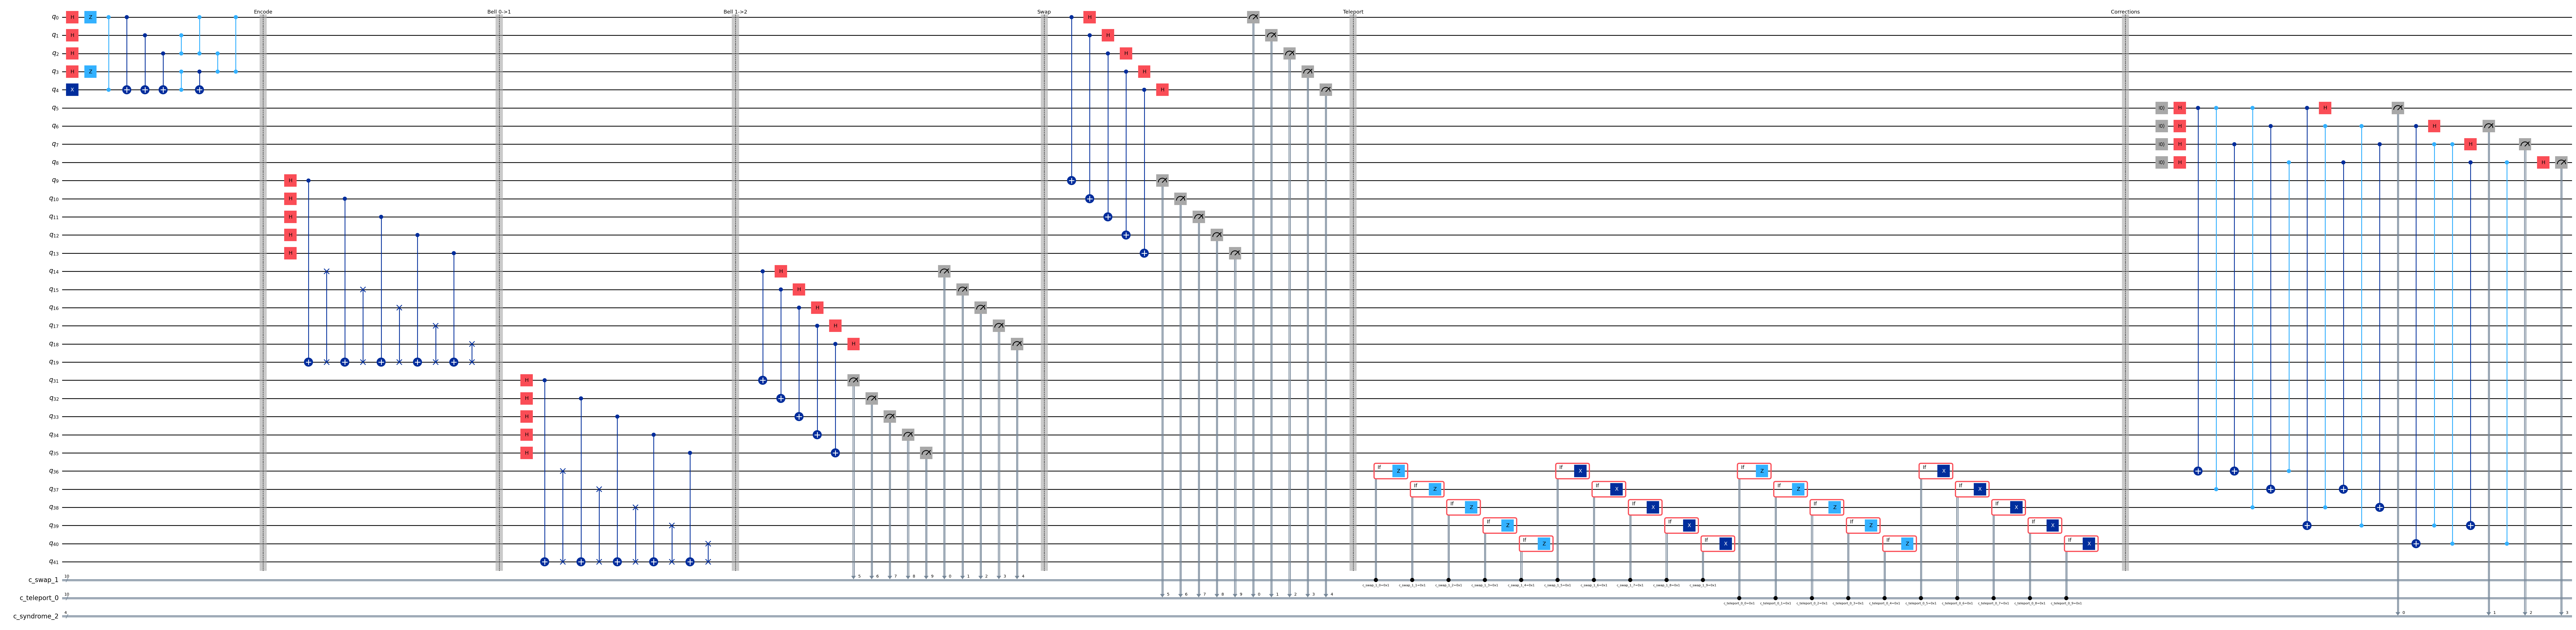

In [49]:
# Draw the circuit BEFORE transpilation to see SWAP gates explicitly
print("Pre-transpiled circuit (SWAPs visible):")
test_circuit.draw('mpl', fold=-1, idle_wires=False)

# Noiseless Simulation Test

In [50]:
# Noiseless simulation (fast - no noise remapping needed)
simulator = AerSimulator(noise_model=None, method='matrix_product_state', seed_simulator=SEED)
transpiled = transpile(test_circuit, basis_gates=FEZ_BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL, seed_transpiler=SEED)

print(f"Transpiled gate counts: {transpiled.count_ops()}")

result = simulator.run(transpiled, shots=NUM_SHOTS, seed_simulator=SEED).result()

# Get syndrome counts
syndrome_reg = test_circuit.cregs[-1]
syndrome_indices = [test_circuit.find_bit(bit).index for bit in syndrome_reg]
syndrome_counts = marginal_distribution(result.get_counts(), indices=syndrome_indices)

print(f"Syndrome counts (noiseless): {dict(sorted(syndrome_counts.items()))}")

Transpiled gate counts: OrderedDict({'rz': 194, 'sx': 156, 'cz': 76, 'measure': 24, 'if_else': 20, 'barrier': 6, 'reset': 4, 'x': 1})
Syndrome counts (noiseless): {'0000': 4096}


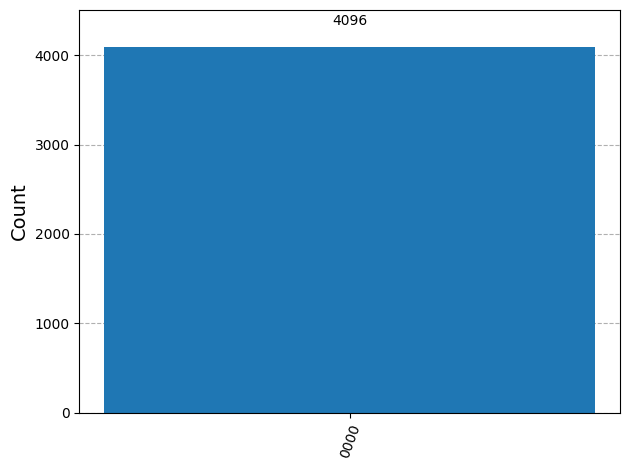

In [51]:
plot_histogram(syndrome_counts)

# Noisy Simulation Test

In [52]:
# Noisy simulation with FIXED allocation noise model
# Build ONE noise model for all circuits (since they all use the same qubit indices)

import time

# Build noise model for FIXED allocation (built once, reused for all paths)
print(f"Building noise model for FIXED allocation ({TOTAL_FIXED_QUBITS} qubits)...")
start = time.time()
FIXED_NOISE_MODEL = build_fixed_noise_model(TOTAL_FIXED_QUBITS, error_rate_2q=ERROR_RATE_2Q)
print(f"Noise model built in {time.time() - start:.2f}s")
print(f"This model will be REUSED for all paths!")

# Create simulator (also reused)
noisy_simulator = AerSimulator(noise_model=FIXED_NOISE_MODEL, method='matrix_product_state', seed_simulator=SEED)

# Run simulation
print(f"\nRunning noisy simulation ({test_circuit.num_qubits} qubits)...")
start = time.time()
noisy_result = noisy_simulator.run(transpiled, shots=NUM_SHOTS, seed_simulator=SEED).result()
print(f"Simulation took {time.time() - start:.2f}s")

noisy_syndrome_counts = marginal_distribution(noisy_result.get_counts(), indices=syndrome_indices)
print(f"\nNoisy syndrome counts: {dict(sorted(noisy_syndrome_counts.items()))}")

# Show no-error fraction
no_error_frac = noisy_syndrome_counts.get('0000', 0) / sum(noisy_syndrome_counts.values())
print(f"No-error fraction: {no_error_frac:.4f}")

Building noise model for FIXED allocation (86 qubits)...
Noise model built in 0.58s
This model will be REUSED for all paths!

Running noisy simulation (86 qubits)...
Simulation took 66.28s

Noisy syndrome counts: {'0000': 2219, '0001': 129, '0010': 172, '0011': 129, '0100': 129, '0101': 149, '0110': 124, '0111': 79, '1000': 178, '1001': 128, '1010': 118, '1011': 86, '1100': 160, '1101': 75, '1110': 128, '1111': 93}
No-error fraction: 0.5417


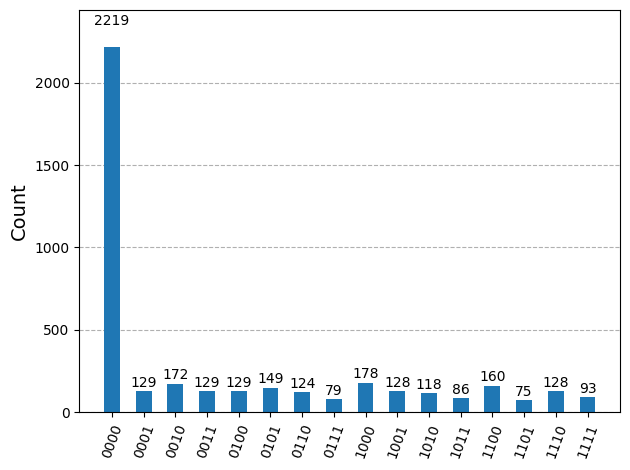

In [53]:
plot_histogram(noisy_syndrome_counts)

# Data Generation

In [54]:
class TimeAwareMeasurement:
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='513_ES'):
        """
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A 16-dimensional numpy array of syndrome counts.
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with additional stats.
        :param code_type: String indicating the code type, e.g., '513_ES' for entanglement swapping.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type

In [ ]:
import time

TIME_AWARE_MEASUREMENTS = []

print("=" * 70)
print("513 ENTANGLEMENT SWAPPING - FIXED ALLOCATION (Consistent Noise)")
print("=" * 70)
print(f"Basis gates: {FEZ_BASIS_GATES}")
print(f"2Q error rate: {ERROR_RATE_2Q}")
print(f"Fixed total qubits: {TOTAL_FIXED_QUBITS}")
print(f"Shots per circuit: {NUM_SHOTS}")
print(f"Total paths: {len(ALL_HOP_PATHS)}")
print("=" * 70)
print("Noise model: SHARED across all paths (consistent edge noise profiles)")
print("=" * 70)

# Build noise model ONCE for all circuits
print("\nBuilding shared noise model...")
noise_model = build_fixed_noise_model(TOTAL_FIXED_QUBITS, error_rate_2q=ERROR_RATE_2Q)
simulator = AerSimulator(noise_model=noise_model, method='matrix_product_state', seed_simulator=SEED)
print("Done!\n")

total_start = time.time()

for path_idx, path in enumerate(ALL_HOP_PATHS):
    path_start = time.time()
    
    # Build circuit with FIXED allocation
    circuit, alloc = build_entanglement_swapping_circuit_fixed(path, initial_state='0')
    
    # Transpile
    transpiled = transpile(circuit, basis_gates=FEZ_BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL, seed_transpiler=SEED)
    
    # Run (using shared noise model and simulator)
    result = simulator.run(transpiled, shots=NUM_SHOTS, seed_simulator=SEED + path_idx).result()
    
    # Extract syndrome
    syndrome_reg = circuit.cregs[-1]
    syndrome_indices = [circuit.find_bit(bit).index for bit in syndrome_reg]
    syndrome_counts = marginal_distribution(result.get_counts(), indices=syndrome_indices)
    
    # Build histogram (ordered by syndrome value)
    histogram = np.array(
        [syndrome_counts.get(f"{i:04b}", 0) for i in range(16)],
        dtype=np.float32
    )
    
    # Store
    path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    elapsed = time.time() - path_start
    
    measurement = TimeAwareMeasurement(
        path_edges=path_edges,
        histogram=histogram,
        duration=elapsed,
        latency_stats={'total_shots': NUM_SHOTS, 'qubits': TOTAL_FIXED_QUBITS, 'allocation': 'fixed'},
        code_type='513_ES_FIXED'
    )
    TIME_AWARE_MEASUREMENTS.append(measurement)
    
    no_error_frac = histogram[0] / histogram.sum()
    edges_str = "->".join(str(e) for e in path)
    print(f"[{path_idx+1:2d}/{len(ALL_HOP_PATHS)}] {edges_str:15s} | {elapsed:5.1f}s | no-error: {no_error_frac:.3f}")

total_elapsed = time.time() - total_start
print(f"\n{'=' * 70}")
print(f"Total: {len(TIME_AWARE_MEASUREMENTS)} measurements in {total_elapsed:.1f}s")
print(f"Average: {total_elapsed/len(ALL_HOP_PATHS):.1f}s per path")
print(f"{'=' * 70}")

513 ENTANGLEMENT SWAPPING - FIXED ALLOCATION (Consistent Noise)
Basis gates: ['cz', 'id', 'rz', 'sx', 'x']
2Q error rate: 0.01
Fixed total qubits: 86
Shots per circuit: 4096
Total paths: 24
Noise model: SHARED across all paths (consistent edge noise profiles)

Building shared noise model...
Done!

[ 1/24] 0->3->4->1      | 361.5s | no-error: 0.441
[ 2/24] 0->1->2         |  65.7s | no-error: 0.524
[ 3/24] 0->1->4->3      | 161.4s | no-error: 0.432
[ 4/24] 0->1->4         |  66.6s | no-error: 0.524
[ 5/24] 0->3->4         |  65.6s | no-error: 0.526
[ 6/24] 0->1->2->5      | 173.2s | no-error: 0.427
[ 7/24] 0->1->4->5      | 168.5s | no-error: 0.428
[ 8/24] 0->3->4->5      | 170.8s | no-error: 0.429
[ 9/24] 1->4->5->2      | 355.5s | no-error: 0.435
[10/24] 1->0->3         |  70.5s | no-error: 0.525
[11/24] 1->4->3         |  61.5s | no-error: 0.524
[12/24] 1->0->3->4      | 166.0s | no-error: 0.431
[13/24] 1->2->5->4      | 161.9s | no-error: 0.422
[14/24] 1->2->5         |  66.9s | no-

# Save Data

In [ ]:
DATA_DIR = '../../pickle_files/syndrome_data_513_es/'
os.makedirs(DATA_DIR, exist_ok=True)

with open(os.path.join(DATA_DIR, 'measurements.pkl'), 'wb') as f:
    pickle.dump(TIME_AWARE_MEASUREMENTS, f)

with open(os.path.join(DATA_DIR, 'graph.pkl'), 'wb') as f:
    pickle.dump(network_graph, f)

print(f"Data saved to {DATA_DIR}")

Data saved to ../../pickle_files/syndrome_data_513_es/


In [ ]:
# =============================================================================
# GROUND TRUTH CIRCUIT (Entanglement Swapping Protocol - FIXED Allocation)
# =============================================================================

def build_ground_truth_circuit_fixed(path, initial_state='0', measurement_basis='Z'):
    """
    Build a ground truth circuit for single-qubit transport via entanglement swapping.
    
    Uses FIXED allocation for consistent noise profiles.
    
    This circuit teleports a SINGLE (unencoded) qubit from source to sink
    using the same entanglement swapping protocol, and measures in the specified
    basis to determine error rates.
    
    Args:
        path: List of node IDs, e.g., [0, 1, 2, 3]
        initial_state: '0' or '1'
        measurement_basis: 'X', 'Y', or 'Z'
    
    Returns:
        tuple: (QuantumCircuit, FixedPathAllocation)
    """
    alloc = FixedPathAllocation(path)
    
    source = path[0]
    sink = path[-1]
    intermediate_nodes = path[1:-1]
    edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    
    # Create circuit with FIXED total qubits
    qc = QuantumCircuit(alloc.total_qubits)
    
    # Classical registers for Bell measurements
    swap_registers = {}
    for node in intermediate_nodes:
        reg = ClassicalRegister(2, name=f'c_swap_{node}')
        qc.add_register(reg)
        swap_registers[node] = reg
    
    teleport_register = ClassicalRegister(2, name=f'c_teleport_{source}')
    qc.add_register(teleport_register)
    
    measure_register = ClassicalRegister(1, name='c_measure')
    qc.add_register(measure_register)
    
    # =========================================================================
    # STEP 1: Prepare initial state at source (use qubit 0 from source_data)
    # =========================================================================
    source_qubit = alloc.source_data[0]
    
    if initial_state == '1':
        qc.x(source_qubit)
    
    if measurement_basis == 'X':
        qc.h(source_qubit)
    elif measurement_basis == 'Y':
        qc.h(source_qubit)
        qc.s(source_qubit)
    
    qc.barrier(label='Init')
    
    # =========================================================================
    # STEP 2: Sequential Bell pair distribution (1 Bell pair per edge)
    # =========================================================================
    for edge in edges:
        sender = edge[0]
        receiver = edge[1]
        edge_key = get_edge_key(sender, receiver)
        
        # Use first qubit of each edge's Bell pair allocation
        if sender < receiver:
            sender_qubit = alloc.edge_qubits[edge_key][0]
            receiver_qubit = alloc.edge_qubits[edge_key][5]
        else:
            sender_qubit = alloc.edge_qubits[edge_key][5]
            receiver_qubit = alloc.edge_qubits[edge_key][0]
        
        path_qubit = alloc.path_qubit[edge_key]
        
        qc.h(sender_qubit)
        qc.cx(sender_qubit, path_qubit)
        qc.swap(path_qubit, receiver_qubit)
    
    qc.barrier(label='Bell Pairs')
    
    # =========================================================================
    # STEP 3: Entanglement swapping at intermediate nodes (single qubit)
    # =========================================================================
    def get_single_node_edge_qubit(node, neighbor):
        edge_key = get_edge_key(node, neighbor)
        if node < neighbor:
            return alloc.edge_qubits[edge_key][0]
        else:
            return alloc.edge_qubits[edge_key][5]
    
    for i, node in enumerate(intermediate_nodes):
        prev_node = path[i]
        next_node = path[i + 2]
        
        incoming_qubit = get_single_node_edge_qubit(node, prev_node)
        outgoing_qubit = get_single_node_edge_qubit(node, next_node)
        
        qc.cx(incoming_qubit, outgoing_qubit)
        qc.h(incoming_qubit)
        qc.measure(incoming_qubit, swap_registers[node][0])
        qc.measure(outgoing_qubit, swap_registers[node][1])
    
    if intermediate_nodes:
        qc.barrier(label='Swap')
    
    # =========================================================================
    # STEP 4: Teleportation from source
    # =========================================================================
    first_neighbor = path[1]
    source_link_qubit = get_single_node_edge_qubit(source, first_neighbor)
    
    qc.cx(source_qubit, source_link_qubit)
    qc.h(source_qubit)
    qc.measure(source_qubit, teleport_register[0])
    qc.measure(source_link_qubit, teleport_register[1])
    
    qc.barrier(label='Teleport')
    
    # =========================================================================
    # STEP 5: Apply Pauli corrections at sink
    # =========================================================================
    last_neighbor = path[-2]
    sink_qubit = get_single_node_edge_qubit(sink, last_neighbor)
    
    for node in intermediate_nodes:
        with qc.if_test((swap_registers[node][0], 1)):
            qc.z(sink_qubit)
        with qc.if_test((swap_registers[node][1], 1)):
            qc.x(sink_qubit)
    
    with qc.if_test((teleport_register[0], 1)):
        qc.z(sink_qubit)
    with qc.if_test((teleport_register[1], 1)):
        qc.x(sink_qubit)
    
    qc.barrier(label='Corrections')
    
    # =========================================================================
    # STEP 6: Rotate back to Z-basis and measure
    # =========================================================================
    if measurement_basis == 'X':
        qc.h(sink_qubit)
    elif measurement_basis == 'Y':
        qc.sdg(sink_qubit)
        qc.h(sink_qubit)
    
    qc.measure(sink_qubit, measure_register[0])
    
    return qc, alloc

# Test Ground Truth Circuit

In [ ]:
# Test ground truth circuit with FIXED allocation
test_path_gt = [0, 1, 2]

# Build with Y-basis measurement
gt_circuit, gt_alloc = build_ground_truth_circuit_fixed(test_path_gt, initial_state='0', measurement_basis='Y')

print(f"Ground truth circuit: Path {test_path_gt}")
print(f"  Total qubits: {gt_circuit.num_qubits} (FIXED allocation)")
print(f"  Classical bits: {gt_circuit.num_clbits}")
print(f"  Gate counts: {gt_circuit.count_ops()}")

gt_circuit.draw('mpl', fold=-1, idle_wires=False)

In [ ]:
# Noiseless test - should give expected output
simulator_gt = AerSimulator(noise_model=None, method='matrix_product_state', seed_simulator=SEED)
transpiled_gt = transpile(gt_circuit, basis_gates=FEZ_BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL, seed_transpiler=SEED)

result_gt = simulator_gt.run(transpiled_gt, shots=4096, seed_simulator=SEED).result()

# Get measurement result (last register)
measure_reg = gt_circuit.cregs[-1]
measure_idx = [gt_circuit.find_bit(bit).index for bit in measure_reg]
measure_counts = marginal_distribution(result_gt.get_counts(), indices=measure_idx)

print(f"Ground truth measurement (noiseless, Y-basis, |0⟩ input):")
print(f"  Expected: '0' (since |0⟩ in Y-basis is |+i⟩, teleported correctly, rotated back)")
print(f"  Counts: {dict(sorted(measure_counts.items()))}")

Ground truth measurement (noiseless, Y-basis, |0⟩ input):
  Expected: '0' (since |0⟩ in Y-basis is |+i⟩, teleported correctly, rotated back)
  Counts: {'0': 4096}


# Ground Truth Data Collection

In [ ]:
def calculate_exact_pauli_rates(z_basis_counts, x_basis_counts, y_basis_counts, expected_state='0'):
    """
    Calculate exact Pauli error rates from three-basis measurements.
    
    For a qubit prepared in |0⟩ and measured in three bases:
    - Z-basis error (measure '1'): X or Y error occurred
    - X-basis error (measure '1'): Z or Y error occurred  
    - Y-basis error (measure '1'): X or Z error occurred
    
    Solving the system:
        E_z = p_x + p_y
        E_x = p_y + p_z
        E_y = p_x + p_z
    
    Gives:
        p_x = (E_z + E_y - E_x) / 2
        p_y = (E_z + E_x - E_y) / 2
        p_z = (E_x + E_y - E_z) / 2
    
    Args:
        z_basis_counts: {'0': n0, '1': n1} from Z-basis measurement
        x_basis_counts: {'0': n0, '1': n1} from X-basis measurement
        y_basis_counts: {'0': n0, '1': n1} from Y-basis measurement
        expected_state: '0' or '1' - the state we prepared
    
    Returns:
        dict with keys 'p_x', 'p_y', 'p_z', 'E_x', 'E_y', 'E_z'
    """
    error_outcome = '1' if expected_state == '0' else '0'
    
    total_z = sum(z_basis_counts.values())
    total_x = sum(x_basis_counts.values())
    total_y = sum(y_basis_counts.values())
    
    E_z = z_basis_counts.get(error_outcome, 0) / total_z
    E_x = x_basis_counts.get(error_outcome, 0) / total_x
    E_y = y_basis_counts.get(error_outcome, 0) / total_y
    
    # Solve for individual Pauli error rates
    p_x = max(0, (E_z + E_y - E_x) / 2)
    p_y = max(0, (E_z + E_x - E_y) / 2)
    p_z = max(0, (E_x + E_y - E_z) / 2)
    
    return {
        'p_x': p_x,
        'p_y': p_y,
        'p_z': p_z,
        'E_x': E_x,
        'E_y': E_y,
        'E_z': E_z
    }

In [ ]:
# =============================================================================
# GROUND TRUTH DATA GENERATION (FIXED Allocation)
# =============================================================================
# Generate Pauli error rates for each edge using entanglement swapping protocol
# Uses FIXED allocation for consistent noise profiles

GROUND_TRUTH_DATA = {}

print("=" * 70)
print("GROUND TRUTH DATA GENERATION (FIXED Allocation)")
print("=" * 70)
print(f"Using FIXED allocation noise model ({TOTAL_FIXED_QUBITS} qubits)")
print(f"Basis gates: {FEZ_BASIS_GATES}")
print(f"2Q error rate: {ERROR_RATE_2Q}")
print(f"Edges to process: {list(network_graph.edges())}")
print("=" * 70)

# Build noise model ONCE (shared across all ground truth measurements)
print("\nBuilding shared noise model for ground truth...")
noise_model_gt = build_fixed_noise_model(TOTAL_FIXED_QUBITS, error_rate_2q=ERROR_RATE_2Q)
noisy_sim_gt = AerSimulator(noise_model=noise_model_gt, method='matrix_product_state', seed_simulator=SEED)
print("Done!\n")

for edge_idx, edge in enumerate(network_graph.edges()):
    path = [edge[0], edge[1]]  # Single hop path
    
    print(f"Edge {edge}:")
    
    # Build circuits for all three bases (using FIXED allocation)
    circuit_Z, _ = build_ground_truth_circuit_fixed(path, initial_state='0', measurement_basis='Z')
    circuit_X, _ = build_ground_truth_circuit_fixed(path, initial_state='0', measurement_basis='X')
    circuit_Y, _ = build_ground_truth_circuit_fixed(path, initial_state='0', measurement_basis='Y')
    
    # Transpile circuits
    transpiled_Z = transpile(circuit_Z, basis_gates=FEZ_BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL, seed_transpiler=SEED)
    transpiled_X = transpile(circuit_X, basis_gates=FEZ_BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL, seed_transpiler=SEED)
    transpiled_Y = transpile(circuit_Y, basis_gates=FEZ_BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL, seed_transpiler=SEED)
    
    print("  Running Z-basis measurement...", end=' | ')
    result_Z = noisy_sim_gt.run(transpiled_Z, shots=NUM_SHOTS, seed_simulator=SEED + edge_idx * 3).result()
    measure_reg_Z = circuit_Z.cregs[-1]
    measure_idx_Z = [circuit_Z.find_bit(bit).index for bit in measure_reg_Z]
    counts_Z = marginal_distribution(result_Z.get_counts(), indices=measure_idx_Z)
    
    print("Running X-basis measurement...", end=' | ')
    result_X = noisy_sim_gt.run(transpiled_X, shots=NUM_SHOTS, seed_simulator=SEED + edge_idx * 3 + 1).result()
    measure_reg_X = circuit_X.cregs[-1]
    measure_idx_X = [circuit_X.find_bit(bit).index for bit in measure_reg_X]
    counts_X = marginal_distribution(result_X.get_counts(), indices=measure_idx_X)
    
    print("Running Y-basis measurement...")
    result_Y = noisy_sim_gt.run(transpiled_Y, shots=NUM_SHOTS, seed_simulator=SEED + edge_idx * 3 + 2).result()
    measure_reg_Y = circuit_Y.cregs[-1]
    measure_idx_Y = [circuit_Y.find_bit(bit).index for bit in measure_reg_Y]
    counts_Y = marginal_distribution(result_Y.get_counts(), indices=measure_idx_Y)
    
    error_rates = calculate_exact_pauli_rates(
        z_basis_counts=counts_Z,
        x_basis_counts=counts_X,
        y_basis_counts=counts_Y,
        expected_state='0'
    )
    
    GROUND_TRUTH_DATA[edge] = [error_rates['p_x'], error_rates['p_y'], error_rates['p_z']]
    print(f"  Pauli Errors: PX={error_rates['p_x']:.6f}, PY={error_rates['p_y']:.6f}, PZ={error_rates['p_z']:.6f}")
    print(f"  Raw error rates: E_x={error_rates['E_x']:.6f}, E_y={error_rates['E_y']:.6f}, E_z={error_rates['E_z']:.6f}")

print(f"\n{'=' * 70}")
print("Ground truth data collection complete (FIXED allocation)")
print(f"{'=' * 70}")

In [ ]:
# Save ground truth data
with open(os.path.join(DATA_DIR, 'ground_truth.pkl'), 'wb') as f:
    pickle.dump(GROUND_TRUTH_DATA, f)

print(f"Ground truth data saved to {DATA_DIR}ground_truth.pkl")
print(f"\nGround truth summary:")
for edge, rates in GROUND_TRUTH_DATA.items():
    print(f"  Edge {edge}: PX={rates[0]:.6f}, PY={rates[1]:.6f}, PZ={rates[2]:.6f}")

Ground truth data saved to ../../pickle_files/syndrome_data_513_es/ground_truth.pkl

Ground truth summary:
  Edge (0, 1): PX=0.016724, PY=0.012817, PZ=0.012329
  Edge (0, 3): PX=0.016724, PY=0.012817, PZ=0.012329
  Edge (1, 2): PX=0.016846, PY=0.012939, PZ=0.012207
  Edge (1, 4): PX=0.016846, PY=0.012939, PZ=0.012207
  Edge (2, 5): PX=0.016846, PY=0.012939, PZ=0.012207
  Edge (3, 4): PX=0.016968, PY=0.012817, PZ=0.012329
  Edge (4, 5): PX=0.016846, PY=0.012939, PZ=0.012451
